# SWEC short-term: HMM post-processing and feature explainability

This notebook is the **post-processing** step of the pipeline.

We use the outputs from the LOSO model notebook to do two things:

1. **HMM smoothing** of window-level seizure probabilities  
2. **Explainability** using the saved fold-level feature importances

This notebook is written for beginners, so each step explains:
- what the code is doing
- why we do it
- what to look for in the outputs

## What this notebook expects

The previous model notebook saves a folder inside:

`derived_ml_swec_short/`

and inside that folder we expect files such as:
- `window_predictions.csv`
- `fold_results.csv`
- `metric_summary.csv`
- `feature_importance_by_fold.csv`
- `feature_importance_summary.csv`

We will load one of those saved model runs and work from there.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Configuration

Set the path to the saved model run.

If `MODEL_RUN_NAME = None`, the notebook will try to use the **most recent** model run it can find.

In [32]:
# ------------------------------------------------------------------
# Main paths
# ------------------------------------------------------------------
ML_DIR = Path("derived_ml_swec_short")
FEATURES_DIR = Path("model__random_forest__features-selected__rfe__mode-metric_stop__score-recall__base-logreg__auto-min-5__tol-0.001__step-1__thr-0.50")


# Optional: choose a specific saved model run.
# Example:
# MODEL_RUN_NAME = "model__logreg__features-all_features__thr-0.50"
MODEL_RUN_NAME = "model__random_forest__features-selected__rfe__mode-metric_stop__score-recall__base-logreg__auto-min-5__tol-0.001__step-1__thr-0.50"
# ------------------------------------------------------------------
# HMM settings
# We use a simple 2-state HMM:
#   state 0 = non-seizure
#   state 1 = seizure
# ------------------------------------------------------------------
P_STAY_NON_SEIZURE = 0.60
P_STAY_SEIZURE = 0.95

# Clip probabilities away from 0 and 1 for numerical stability
EMISSION_EPS = 1e-6

# Use the model's probability column as the HMM emission signal
PROBABILITY_COLUMN = "prob_seizure"

# Which column defines the time order inside each recording?
WINDOW_ORDER_COLUMN = "window_index"

# Optionally inspect only a few recordings in plots
MAX_RECORDING_PLOTS = 8

# Plotting settings
TIME_AXIS_MODE = "minutes"   # "seconds", "minutes", or "window_index"
PLOT_SUBJECT_ID = None       # Example: "ID1"
PLOT_RECORDING_ID = None     # Example: "ID1__Sz01"


## Load the saved model run

A *model run* is one completed LOSO experiment, for example:
- logistic regression with all features
- random forest with selected features
- XGBoost with selected features

We load the tables saved by that run.

In [33]:
if not ML_DIR.exists():
    raise FileNotFoundError(
        f"Could not find the model output folder: {ML_DIR.resolve()}\n"
        "Please run the LOSO model notebook first."
    )

all_run_dirs = sorted([p for p in ML_DIR.iterdir() if p.is_dir() and p.name.startswith("model__")])

if not all_run_dirs:
    raise FileNotFoundError(
        f"No saved model runs were found inside: {ML_DIR.resolve()}\n"
        "Please run the LOSO model notebook first."
    )

if MODEL_RUN_NAME is None:
    run_dir = max(all_run_dirs, key=lambda p: p.stat().st_mtime)
else:
    run_dir = ML_DIR / MODEL_RUN_NAME

if not run_dir.exists():
    raise FileNotFoundError(f"Requested run folder does not exist: {run_dir.resolve()}")

predictions_path = run_dir / "window_predictions.csv"
fold_results_path = run_dir / "fold_results.csv"
metric_summary_path = run_dir / "metric_summary.csv"
fi_by_fold_path = run_dir / "feature_importance_by_fold.csv"
fi_summary_path = run_dir / "feature_importance_summary.csv"
subject_balance_path = run_dir / "subject_balance.csv"
overall_balance_path = run_dir / "overall_balance.csv"

required_paths = [predictions_path, fold_results_path, metric_summary_path]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Some required model outputs are missing:\n" + "\n".join(missing))

predictions_df = pd.read_csv(predictions_path)
fold_results_df = pd.read_csv(fold_results_path)
metric_summary_df = pd.read_csv(metric_summary_path)

feature_importance_df = pd.read_csv(fi_by_fold_path) if fi_by_fold_path.exists() else pd.DataFrame()
feature_importance_summary_df = pd.read_csv(fi_summary_path) if fi_summary_path.exists() else pd.DataFrame()
subject_balance_df = pd.read_csv(subject_balance_path) if subject_balance_path.exists() else pd.DataFrame()
overall_balance_df = pd.read_csv(overall_balance_path) if overall_balance_path.exists() else pd.DataFrame()

print("Using model run:")
print(run_dir.resolve())
print()
print("Loaded tables:")
for p in [predictions_path, fold_results_path, metric_summary_path, fi_by_fold_path, fi_summary_path]:
    print(f"- {p.name}: {'found' if p.exists() else 'not found'}")

Using model run:
C:\Users\rescic\PycharmProjects\eeg_ml\notebooks\derived_ml_swec_short\model__random_forest__features-selected__rfe__mode-metric_stop__score-recall__base-logreg__auto-min-5__tol-0.001__step-1__thr-0.50

Loaded tables:
- window_predictions.csv: found
- fold_results.csv: found
- metric_summary.csv: found
- feature_importance_by_fold.csv: found
- feature_importance_summary.csv: found


## Quick look at the loaded data

At this stage, each row in `predictions_df` is one EEG window from the held-out subject in a LOSO fold.

Important columns:
- `subject_id`
- `recording_id`
- `window_idx`
- `true_label`
- `pred_label`
- `prob_seizure`

In [34]:
print("Predictions shape:", predictions_df.shape)
display(predictions_df.head())

print("Fold results shape:", fold_results_df.shape)
display(fold_results_df.head())

Predictions shape: (31774, 15)


,fold,held_out_subject,subject_id,recording_id,window_index,window_start_s,window_end_s,true_label_text,true_label,pred_label,prob_non_seizure,prob_seizure,used_threshold,model_name,n_features_used
0,1,ID1,ID1,ID1__Sz1,0,0.0,2.0,non_seizure,0,0,0.753333,0.246667,0.5,random_forest,6
1,1,ID1,ID1,ID1__Sz1,1,1.5,3.5,non_seizure,0,0,0.540000,0.460000,0.5,random_forest,6
2,1,ID1,ID1,ID1__Sz1,2,3.0,5.0,non_seizure,0,1,0.436667,0.563333,0.5,random_forest,6
3,1,ID1,ID1,ID1__Sz1,3,4.5,6.5,non_seizure,0,0,0.653333,0.346667,0.5,random_forest,6
4,1,ID1,ID1,ID1__Sz1,4,6.0,8.0,non_seizure,0,0,0.640000,0.360000,0.5,random_forest,6


Fold results shape: (18, 20)


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,fold,held_out_subject,n_train_rows,n_test_rows,n_train_subjects,n_test_subjects,n_features_used,positive_rate_train,positive_rate_test
0,0.800912,0.528250,0.286275,0.115324,0.164414,0.566349,0.247118,2912,182,560,73,1,ID1,28047,3727,17,1,6,0.278711,0.169842
1,0.972691,0.734263,0.838710,0.472727,0.604651,0.883545,0.690954,1185,5,29,26,2,ID10,30529,1245,17,1,5,0.274984,0.044177
2,0.935897,0.864865,1.000000,0.729730,0.843750,0.862736,0.846025,476,0,40,108,3,ID11,31150,624,17,1,16,0.266517,0.237179
3,0.852526,0.745322,0.408207,0.605769,0.487742,0.828112,0.600111,2106,274,123,189,4,ID12,29082,2692,17,1,7,0.279829,0.115899
4,0.737391,0.631382,0.320690,0.469697,0.381148,0.681518,0.412501,755,197,105,93,5,ID13a,30624,1150,17,1,5,0.269462,0.172174


## Raw model performance

Before adding any HMM smoothing, we first inspect the original window-level performance.

In [35]:
metric_summary_df

,metric,mean,std,min,max
0,accuracy,0.778829,0.143413,0.447405,0.972691
1,balanced_accuracy,0.657605,0.105027,0.516418,0.864865
2,precision,0.662985,0.285942,0.286275,1.000000
3,recall,0.438030,0.246065,0.032836,0.852459
4,f1,0.460038,0.227905,0.063584,0.843750
5,roc_auc,0.766285,0.116484,0.566349,0.942644
6,pr_auc,0.605529,0.226424,0.247118,0.884693


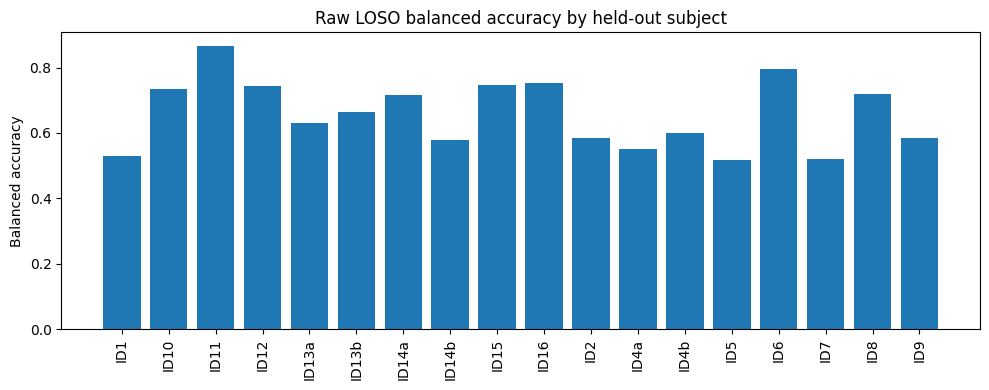

In [36]:
plt.figure(figsize=(10, 4))
plot_df = fold_results_df.sort_values("held_out_subject")
plt.bar(plot_df["held_out_subject"], plot_df["balanced_accuracy"])
plt.xticks(rotation=90)
plt.ylabel("Balanced accuracy")
plt.title("Raw LOSO balanced accuracy by held-out subject")
plt.tight_layout()
plt.show()

## Why use an HMM here?

The classifier predicts each window independently.

But seizure activity is **temporally continuous**:
- seizures usually last for many consecutive windows
- isolated single-window flips are often unrealistic

A Hidden Markov Model (HMM) helps us add a simple temporal rule:

- the hidden state is either **non-seizure** or **seizure**
- the state usually stays the same from one window to the next
- the model probabilities act as the evidence for each state

In this notebook we use a **2-state HMM** with a simple Viterbi decoder.

## HMM transition matrix

We define two probabilities:

- `P_STAY_NON_SEIZURE`
- `P_STAY_SEIZURE`

From them we build the transition matrix:

$$
A =
\begin{bmatrix}
P(0 \to 0) & P(0 \to 1) \\
P(1 \to 0) & P(1 \to 1)
\end{bmatrix}
=
\begin{bmatrix}
p_{00} & 1-p_{00} \\
1-p_{11} & p_{11}
\end{bmatrix}
$$

Large values mean the model prefers **state persistence**.

In [37]:
def build_transition_matrix(p_stay_non_seizure: float, p_stay_seizure: float) -> np.ndarray:
    return np.array([
        [p_stay_non_seizure, 1.0 - p_stay_non_seizure],
        [1.0 - p_stay_seizure, p_stay_seizure],
    ], dtype=float)

A = build_transition_matrix(P_STAY_NON_SEIZURE, P_STAY_SEIZURE)
transition_df = pd.DataFrame(
    A,
    index=["from_non_seizure", "from_seizure"],
    columns=["to_non_seizure", "to_seizure"],
)
transition_df

,to_non_seizure,to_seizure
from_non_seizure,0.60,0.40
from_seizure,0.05,0.95


## Viterbi decoding

We do not need a large HMM library for this step.

Instead, we implement a small Viterbi decoder directly:
- the input is the sequence of seizure probabilities for one recording
- the output is the most likely sequence of hidden states

In [38]:
def viterbi_binary_from_prob(prob_seizure, p_stay_non_seizure=0.995, p_stay_seizure=0.980, eps=1e-6):
    prob_seizure = np.asarray(prob_seizure, dtype=float)
    prob_seizure = np.clip(prob_seizure, eps, 1.0 - eps)
    prob_non_seizure = 1.0 - prob_seizure

    # Transition matrix
    A = build_transition_matrix(p_stay_non_seizure, p_stay_seizure)
    logA = np.log(np.clip(A, eps, 1.0))

    # Initial probabilities: start in non-seizure unless the model evidence is very strong otherwise
    pi = np.array([0.99, 0.01], dtype=float)
    logpi = np.log(np.clip(pi, eps, 1.0))

    T = len(prob_seizure)
    if T == 0:
        return np.array([], dtype=int)

    # Emission log-likelihoods from model probabilities
    # state 0 -> use prob_non_seizure
    # state 1 -> use prob_seizure
    logB = np.column_stack([
        np.log(prob_non_seizure),
        np.log(prob_seizure),
    ])

    dp = np.zeros((T, 2), dtype=float)
    ptr = np.zeros((T, 2), dtype=int)

    dp[0] = logpi + logB[0]

    for t in range(1, T):
        for s in range(2):
            candidates = dp[t - 1] + logA[:, s]
            ptr[t, s] = int(np.argmax(candidates))
            dp[t, s] = np.max(candidates) + logB[t, s]

    states = np.zeros(T, dtype=int)
    states[-1] = int(np.argmax(dp[-1]))

    for t in range(T - 2, -1, -1):
        states[t] = ptr[t + 1, states[t + 1]]

    return states

## Apply the HMM per recording

This is important.

We do **not** smooth across different recordings.  
We smooth only within each `recording_id`, because time continuity only makes sense inside the same seizure file.

In [39]:
required_prediction_cols = [
    "subject_id", "recording_id", WINDOW_ORDER_COLUMN, "true_label", "pred_label", PROBABILITY_COLUMN
]
missing_cols = [c for c in required_prediction_cols if c not in predictions_df.columns]
if missing_cols:
    raise ValueError(
        "The prediction table is missing required columns:\n" + "\n".join(missing_cols)
    )

predictions_sorted = predictions_df.sort_values(
    ["subject_id", "recording_id", WINDOW_ORDER_COLUMN]
).reset_index(drop=True)

hmm_rows = []

for (subject_id, recording_id), group in predictions_sorted.groupby(["subject_id", "recording_id"], sort=False):
    g = group.sort_values(WINDOW_ORDER_COLUMN).copy()
    probs = g[PROBABILITY_COLUMN].values
    hmm_state = viterbi_binary_from_prob(
        probs,
        p_stay_non_seizure=P_STAY_NON_SEIZURE,
        p_stay_seizure=P_STAY_SEIZURE,
        eps=EMISSION_EPS,
    )
    g["hmm_pred_label"] = hmm_state
    hmm_rows.append(g)

hmm_df = pd.concat(hmm_rows, ignore_index=True)
display(hmm_df.head())

,fold,held_out_subject,subject_id,recording_id,window_index,window_start_s,window_end_s,true_label_text,true_label,pred_label,prob_non_seizure,prob_seizure,used_threshold,model_name,n_features_used,hmm_pred_label
0,1,ID1,ID1,ID1__Sz1,0,0.0,2.0,non_seizure,0,0,0.753333,0.246667,0.5,random_forest,6,0
1,1,ID1,ID1,ID1__Sz1,1,1.5,3.5,non_seizure,0,0,0.540000,0.460000,0.5,random_forest,6,0
2,1,ID1,ID1,ID1__Sz1,2,3.0,5.0,non_seizure,0,1,0.436667,0.563333,0.5,random_forest,6,0
3,1,ID1,ID1,ID1__Sz1,3,4.5,6.5,non_seizure,0,0,0.653333,0.346667,0.5,random_forest,6,0
4,1,ID1,ID1,ID1__Sz1,4,6.0,8.0,non_seizure,0,0,0.640000,0.360000,0.5,random_forest,6,0


## Compare raw predictions and HMM-smoothed predictions

We compute the same metrics twice:

- once for the original classifier output
- once after HMM smoothing

In [40]:
def compute_binary_metrics(y_true, y_pred, y_prob):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"] = recall_score(y_true, y_pred, zero_division=0)
    out["f1"] = f1_score(y_true, y_pred, zero_division=0)

    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out["tn"] = int(tn)
    out["fp"] = int(fp)
    out["fn"] = int(fn)
    out["tp"] = int(tp)
    return out

raw_metrics = compute_binary_metrics(
    y_true=hmm_df["true_label"].values,
    y_pred=hmm_df["pred_label"].values,
    y_prob=hmm_df[PROBABILITY_COLUMN].values,
)

hmm_metrics = compute_binary_metrics(
    y_true=hmm_df["true_label"].values,
    y_pred=hmm_df["hmm_pred_label"].values,
    y_prob=hmm_df[PROBABILITY_COLUMN].values,
)

comparison_df = pd.DataFrame([
    {"version": "raw_model", **raw_metrics},
    {"version": "hmm_smoothed", **hmm_metrics},
])
comparison_df

,version,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,raw_model,0.756751,0.645904,0.558211,0.409112,0.472171,0.714123,0.517977,20588,2736,4993,3457
1,hmm_smoothed,0.762133,0.672890,0.561449,0.482249,0.518844,0.714123,0.517977,20141,3183,4375,4075


Notice that ROC-AUC and PR-AUC are based on probabilities, so they do not change here.

What changes are the metrics based on the **final labels**:
- accuracy
- balanced accuracy
- precision
- recall
- F1

In [41]:
fold_compare_rows = []

for held_out_subject, g in hmm_df.groupby("held_out_subject"):
    raw_m = compute_binary_metrics(
        y_true=g["true_label"].values,
        y_pred=g["pred_label"].values,
        y_prob=g[PROBABILITY_COLUMN].values,
    )
    hmm_m = compute_binary_metrics(
        y_true=g["true_label"].values,
        y_pred=g["hmm_pred_label"].values,
        y_prob=g[PROBABILITY_COLUMN].values,
    )
    for version_name, metric_dict in [("raw_model", raw_m), ("hmm_smoothed", hmm_m)]:
        fold_compare_rows.append({
            "held_out_subject": held_out_subject,
            "version": version_name,
            **metric_dict,
        })

fold_compare_df = pd.DataFrame(fold_compare_rows)
display(fold_compare_df.head())

,held_out_subject,version,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,ID1,raw_model,0.800912,0.528250,0.286275,0.115324,0.164414,0.566349,0.247118,2912,182,560,73
1,ID1,hmm_smoothed,0.811376,0.516961,0.281250,0.071090,0.113493,0.566349,0.247118,2979,115,588,45
2,ID10,raw_model,0.972691,0.734263,0.838710,0.472727,0.604651,0.883545,0.690954,1185,5,29,26
3,ID10,hmm_smoothed,0.987952,0.863636,1.000000,0.727273,0.842105,0.883545,0.690954,1190,0,15,40
4,ID11,raw_model,0.935897,0.864865,1.000000,0.729730,0.843750,0.862736,0.846025,476,0,40,108


version,hmm_smoothed,raw_model,delta_hmm_minus_raw
held_out_subject,,,
ID1,0.516961,0.528250,-0.011289
ID10,0.863636,0.734263,0.129374
ID11,0.864865,0.864865,0.000000
ID12,0.809742,0.745322,0.064420
ID13a,0.720514,0.631382,0.089132
ID13b,0.660846,0.663624,-0.002778
ID14a,0.605069,0.717734,-0.112665
ID14b,0.599654,0.577576,0.022077
ID15,0.746479,0.747259,-0.000780


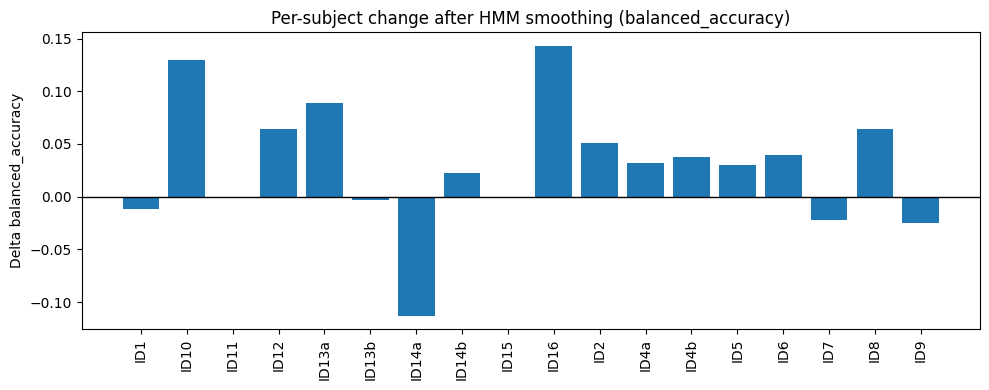

In [42]:
metric_to_plot = "balanced_accuracy"

pivot = fold_compare_df.pivot(index="held_out_subject", columns="version", values=metric_to_plot).sort_index()
pivot["delta_hmm_minus_raw"] = pivot["hmm_smoothed"] - pivot["raw_model"]
display(pivot)

plt.figure(figsize=(10, 4))
plt.bar(pivot.index, pivot["delta_hmm_minus_raw"])
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=90)
plt.ylabel(f"Delta {metric_to_plot}")
plt.title(f"Per-subject change after HMM smoothing ({metric_to_plot})")
plt.tight_layout()
plt.show()

## Confusion matrices: raw vs HMM

These tables help us see whether HMM smoothing reduces isolated false positives or increases false negatives.

In [43]:
cm_raw = confusion_matrix(hmm_df["true_label"], hmm_df["pred_label"], labels=[0, 1])
cm_hmm = confusion_matrix(hmm_df["true_label"], hmm_df["hmm_pred_label"], labels=[0, 1])

cm_raw_df = pd.DataFrame(
    cm_raw,
    index=["true_non_seizure", "true_seizure"],
    columns=["pred_non_seizure", "pred_seizure"]
)
cm_hmm_df = pd.DataFrame(
    cm_hmm,
    index=["true_non_seizure", "true_seizure"],
    columns=["pred_non_seizure", "pred_seizure"]
)

print("Raw model confusion matrix")
display(cm_raw_df)

print("HMM-smoothed confusion matrix")
display(cm_hmm_df)

Raw model confusion matrix


,pred_non_seizure,pred_seizure
true_non_seizure,20588,2736
true_seizure,4993,3457


HMM-smoothed confusion matrix


,pred_non_seizure,pred_seizure
true_non_seizure,20141,3183
true_seizure,4375,4075


## Recording-level probability and timeline plots

These plots are very useful for beginners.

For each recording we show:
- **Top panel:** the model seizure probability over time
- **Bottom panel:** the true labels, the raw model predictions, and the HMM-smoothed predictions

This makes it easier to see:
- when the model becomes confident that a seizure is happening
- whether the raw predictions are noisy
- whether HMM smoothing removes isolated false alarms
- whether the predicted seizure period lines up with the true seizure period


In [44]:
recording_summary = (
    hmm_df.groupby(["subject_id", "recording_id"])
    .agg(
        n_windows=(WINDOW_ORDER_COLUMN, "count"),
        mean_prob_seizure=(PROBABILITY_COLUMN, "mean"),
        seizure_fraction=("true_label", "mean"),
    )
    .reset_index()
)

display(recording_summary.head(10))

,subject_id,recording_id,n_windows,mean_prob_seizure,seizure_fraction
0,ID1,ID1__Sz1,323,0.182539,0.263158
1,ID1,ID1__Sz10,247,0.300567,0.036437
2,ID1,ID1__Sz11,253,0.175731,0.059289
3,ID1,ID1__Sz12,288,0.195509,0.173611
4,ID1,ID1__Sz13,271,0.251341,0.121771
5,ID1,ID1__Sz2,286,0.162308,0.167832
6,ID1,ID1__Sz3,330,0.153485,0.278788
7,ID1,ID1__Sz4,246,0.178672,0.032520
8,ID1,ID1__Sz5,407,0.159353,0.415233
9,ID1,ID1__Sz6,279,0.195651,0.146953


In [45]:
PLOT_SUBJECT_ID = "ID16"

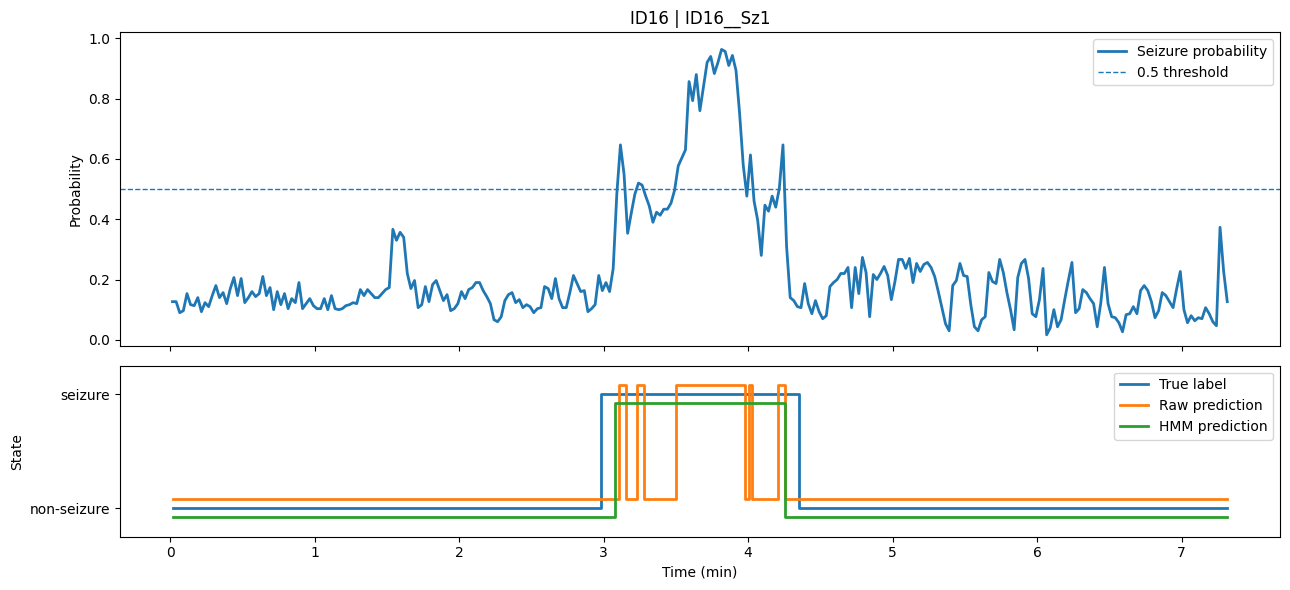

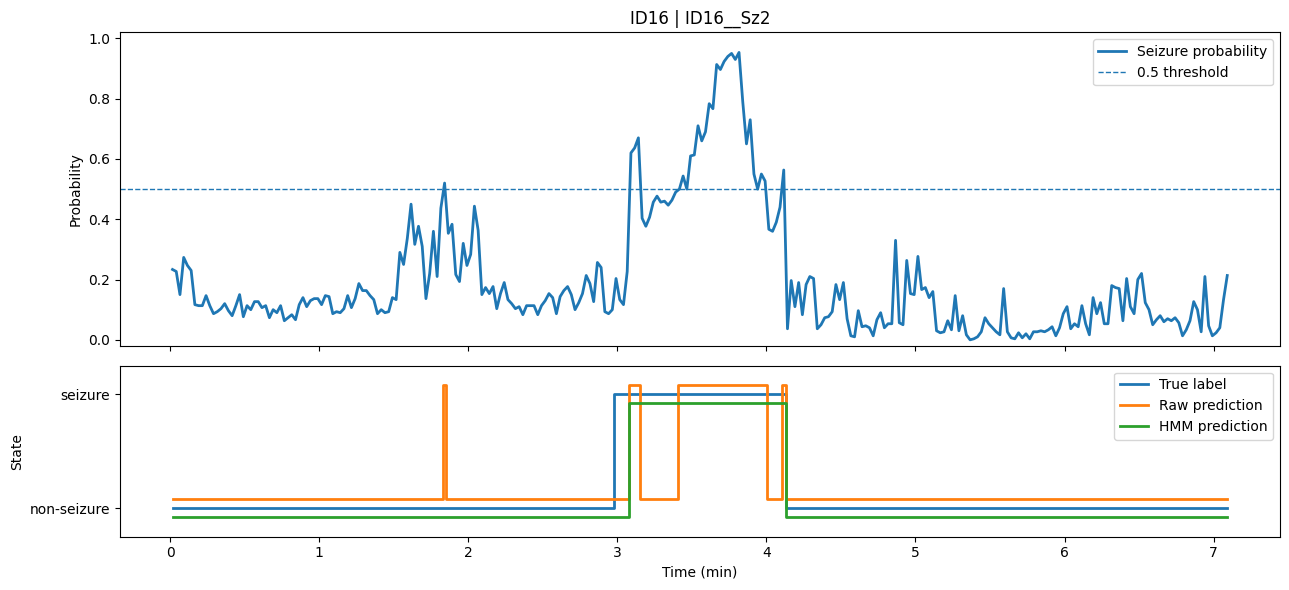

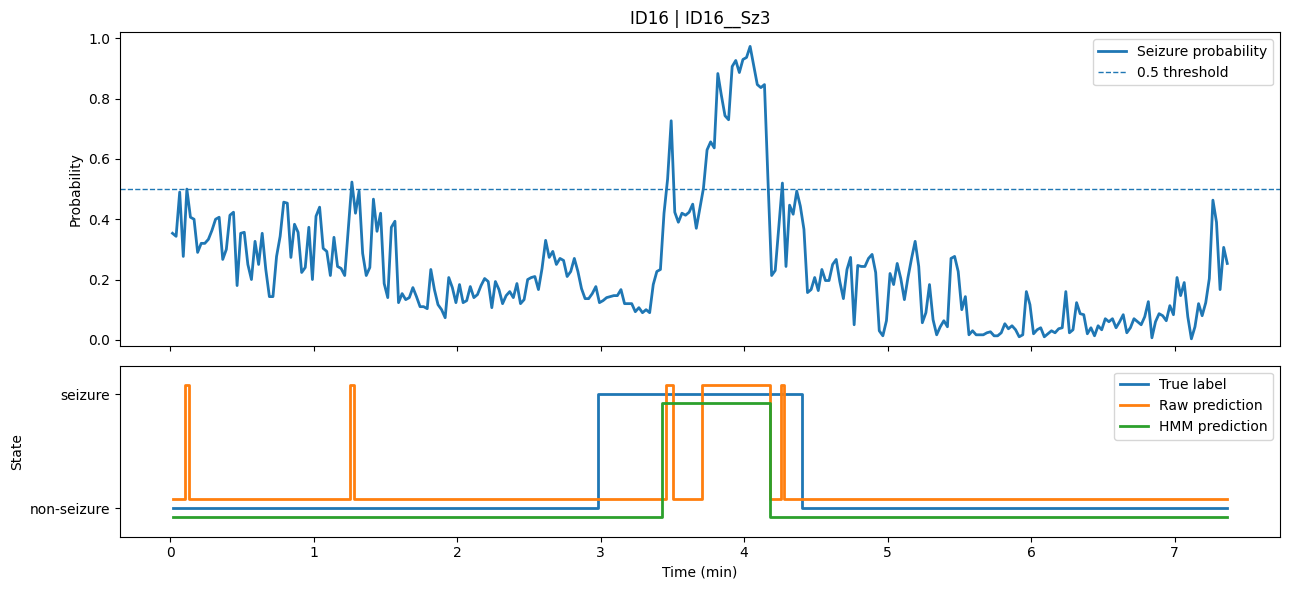

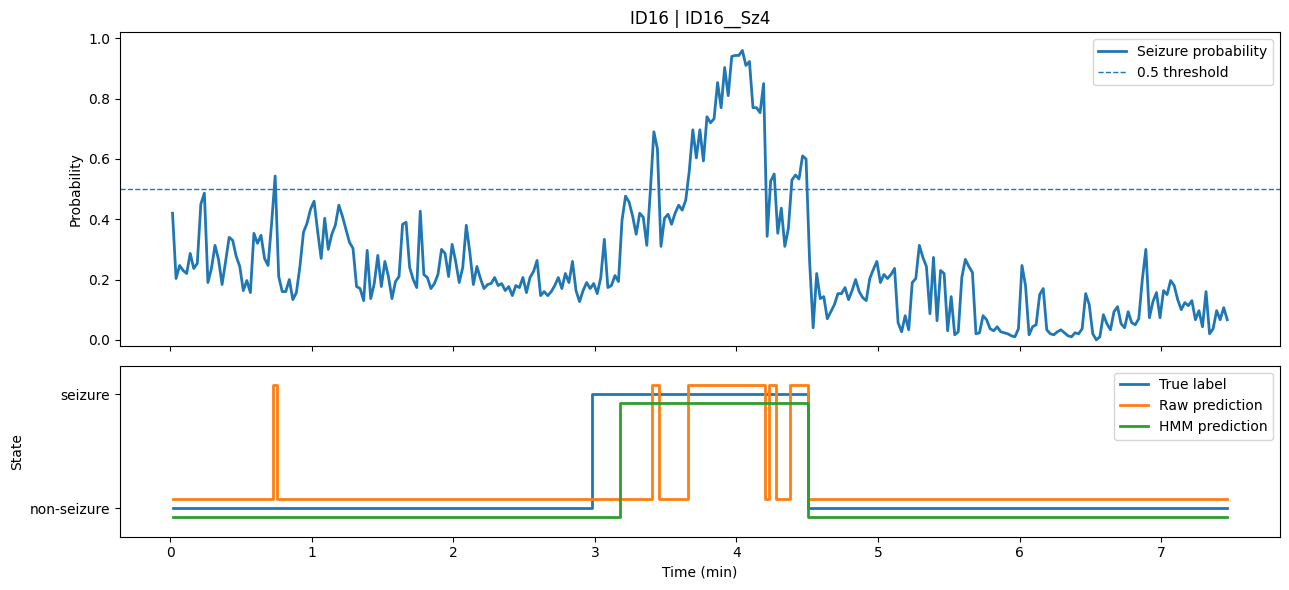

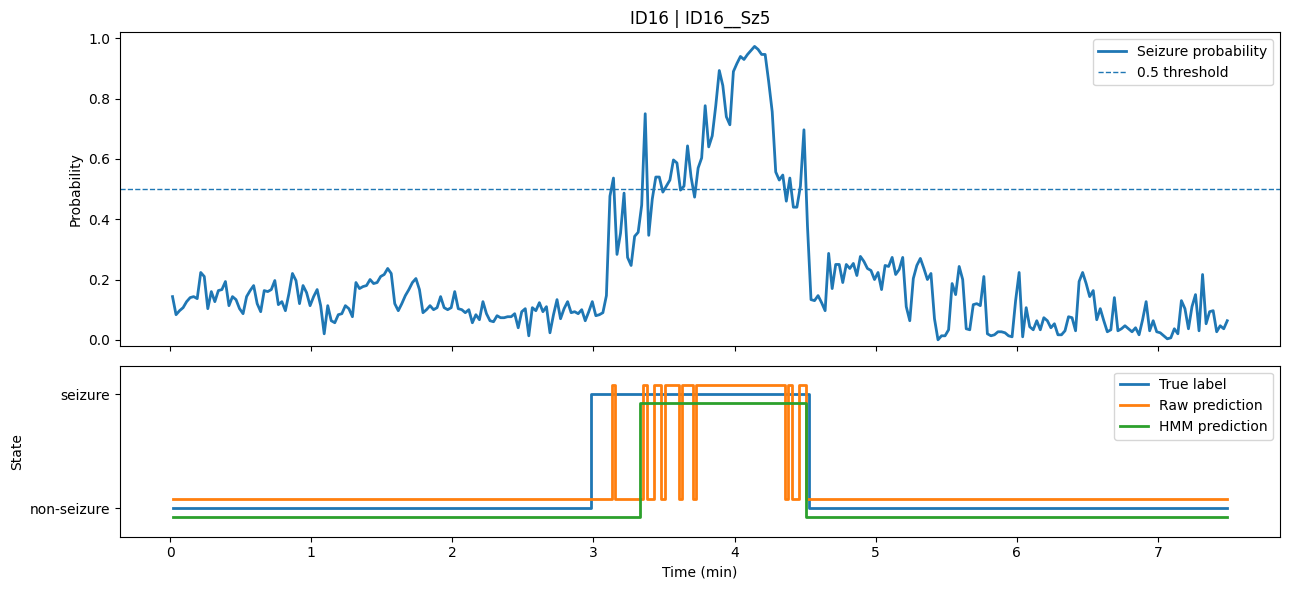

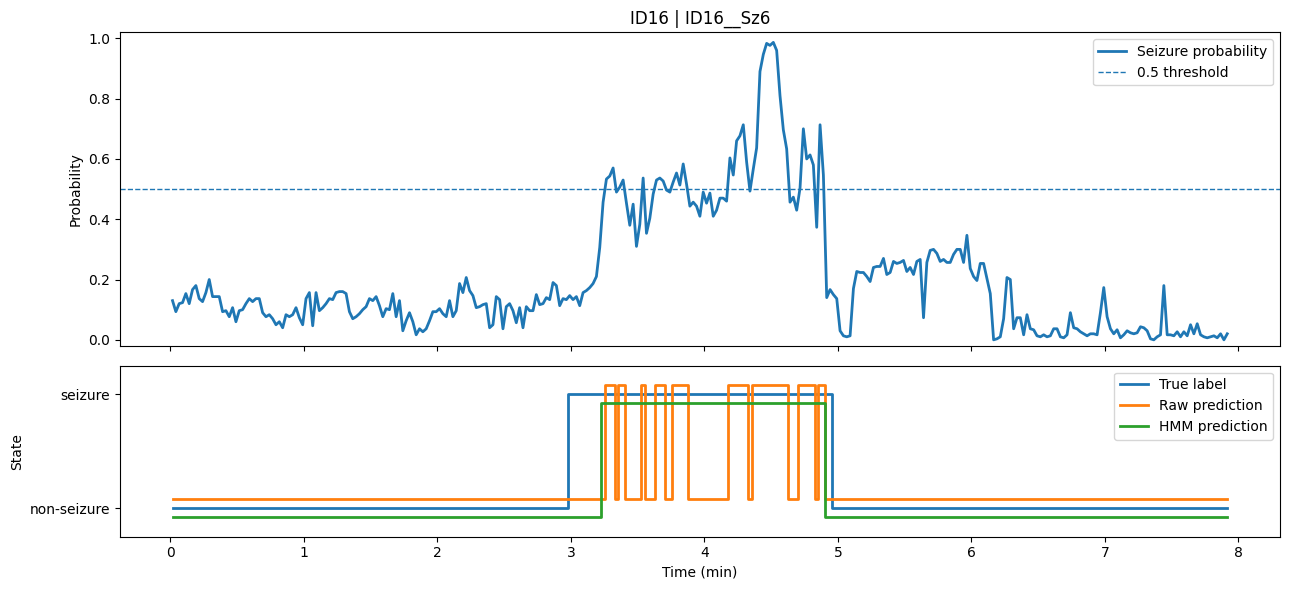

In [46]:

# Choose which recordings to plot
if PLOT_SUBJECT_ID is not None:
    plot_source = recording_summary[recording_summary["subject_id"] == PLOT_SUBJECT_ID].copy()
else:
    plot_source = recording_summary.copy()

if PLOT_RECORDING_ID is not None:
    plot_source = plot_source[plot_source["recording_id"] == PLOT_RECORDING_ID].copy()

plot_keys = plot_source[["subject_id", "recording_id"]].head(MAX_RECORDING_PLOTS).values.tolist()

for subject_id, recording_id in plot_keys:
    g = hmm_df[(hmm_df["subject_id"] == subject_id) & (hmm_df["recording_id"] == recording_id)].copy()
    g = g.sort_values(WINDOW_ORDER_COLUMN).reset_index(drop=True)

    # Build a time axis
    has_window_times = (
        "window_start_s" in g.columns
        and "window_end_s" in g.columns
        and g["window_start_s"].notna().all()
        and g["window_end_s"].notna().all()
    )

    if TIME_AXIS_MODE == "window_index" or not has_window_times:
        x = g[WINDOW_ORDER_COLUMN].values
        x_label = "Window index"
    else:
        # Use the midpoint of each window so probabilities and labels are aligned in time
        x_seconds = 0.5 * (g["window_start_s"].values + g["window_end_s"].values)
        if TIME_AXIS_MODE == "seconds":
            x = x_seconds
            x_label = "Time (s)"
        elif TIME_AXIS_MODE == "minutes":
            x = x_seconds / 60.0
            x_label = "Time (min)"
        else:
            raise ValueError("TIME_AXIS_MODE must be 'seconds', 'minutes', or 'window_index'.")

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(13, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.2]},
    )

    # Top panel: probability trace
    axes[0].plot(x, g[PROBABILITY_COLUMN].values, linewidth=2, label="Seizure probability")
    axes[0].axhline(0.5, linestyle="--", linewidth=1, label="0.5 threshold")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].set_ylabel("Probability")
    axes[0].set_title(f"{subject_id} | {recording_id}")
    axes[0].legend(loc="upper right")

    # Bottom panel: true vs raw vs HMM state timeline
    axes[1].step(x, g["true_label"].values + 0.00, where="mid", linewidth=2, label="True label")
    axes[1].step(x, g["pred_label"].values + 0.08, where="mid", linewidth=2, label="Raw prediction")
    axes[1].step(x, g["hmm_pred_label"].values - 0.08, where="mid", linewidth=2, label="HMM prediction")
    axes[1].set_ylim(-0.25, 1.25)
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(["non-seizure", "seizure"])
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("State")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


## Explainability: what features mattered most?

If the model notebook saved feature importances or coefficients, we can summarize them here.

Examples:
- logistic regression -> coefficients
- linear SVM -> coefficients
- random forest -> feature importances
- XGBoost -> feature importances

These numbers are not all interpreted in the same way, but they are still useful for:
- ranking features
- checking stability across folds
- finding repeatedly important signals

In [47]:
if feature_importance_summary_df.empty:
    print("No saved feature importance summary was found for this model run.")
else:
    print("Feature importance summary shape:", feature_importance_summary_df.shape)
    display(feature_importance_summary_df.head(20))

Feature importance summary shape: (39, 4)


,feature_name,mean_importance,mean_abs_importance,selected_in_folds
0,amp_var__ch10,0.154167,0.154167,1
1,fractal_katz__ch09,0.144221,0.144221,10
2,fractal_katz__ch17,0.127400,0.127400,15
3,line_length__ch17,0.116045,0.116045,11
4,line_length__ch16,0.107890,0.107890,10
5,fractal_katz__ch14,0.103198,0.103198,15
6,line_length__ch02,0.100977,0.100977,12
7,amp_var__ch09,0.090915,0.090915,5
8,fractal_katz__ch03,0.088290,0.088290,15
9,line_length__ch03,0.083948,0.083948,14


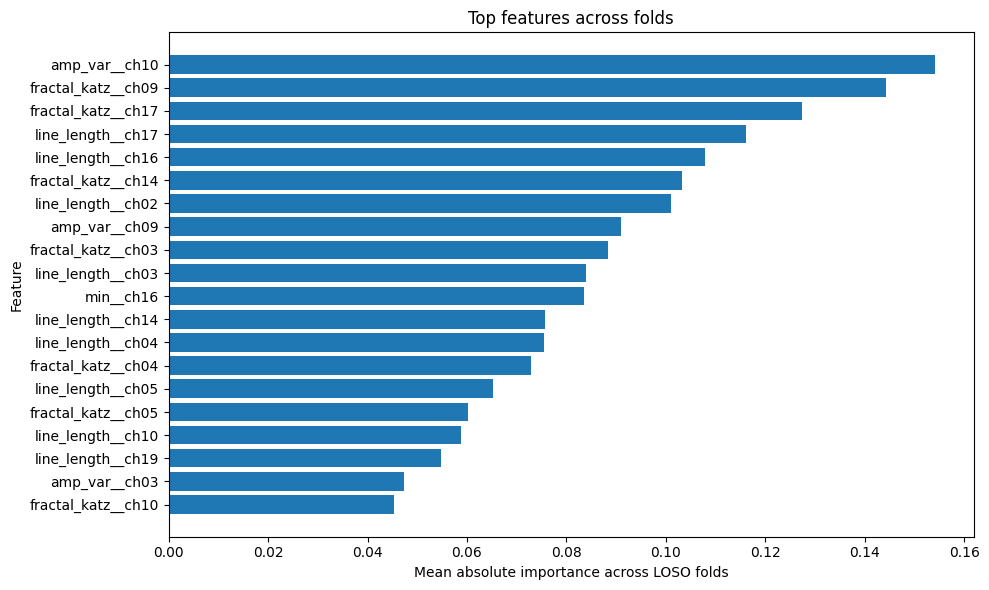

In [48]:
if not feature_importance_summary_df.empty:
    top_n = min(20, len(feature_importance_summary_df))
    top_df = feature_importance_summary_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["feature_name"], top_df["mean_abs_importance"])
    plt.xlabel("Mean absolute importance across LOSO folds")
    plt.ylabel("Feature")
    plt.title("Top features across folds")
    plt.tight_layout()
    plt.show()

### Stability across folds

A feature is often more convincing if it appears as important in **many** LOSO folds, not only in one subject.

So we also look at:
- `selected_in_folds`
- mean importance magnitude across folds

In [49]:
if not feature_importance_summary_df.empty:
    stability_cols = [c for c in ["feature_name", "mean_abs_importance", "selected_in_folds"] if c in feature_importance_summary_df.columns]
    stability_df = feature_importance_summary_df[stability_cols].copy()
    stability_df = stability_df.sort_values(
        ["selected_in_folds", "mean_abs_importance"],
        ascending=[False, False]
    ).reset_index(drop=True)

    display(stability_df.head(25))

,feature_name,mean_abs_importance,selected_in_folds
0,fractal_katz__ch17,0.127400,15
1,fractal_katz__ch14,0.103198,15
2,fractal_katz__ch03,0.088290,15
3,line_length__ch03,0.083948,14
4,fractal_katz__ch04,0.072948,13
5,line_length__ch02,0.100977,12
6,line_length__ch17,0.116045,11
7,line_length__ch04,0.075516,11
8,fractal_katz__ch09,0.144221,10
9,line_length__ch16,0.107890,10


## Fold-by-fold feature heatmap

This plot answers a useful question:

> Does the same feature matter for many held-out subjects, or only for a few?

We show the top features on rows and held-out subjects on columns.

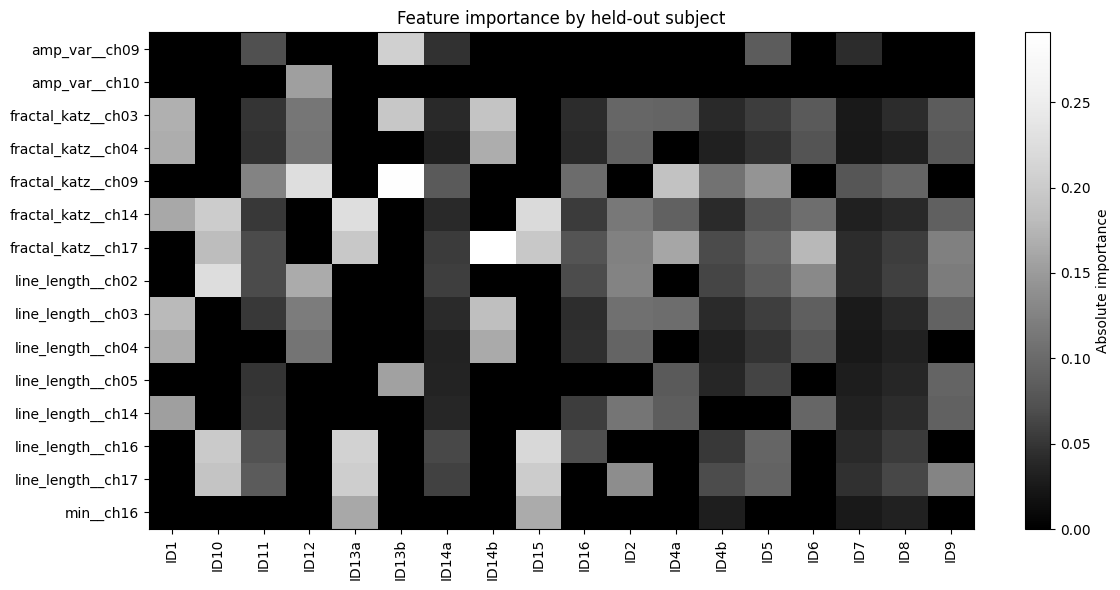

held_out_subject,ID1,ID10,ID11,ID12,ID13a,ID13b,ID14a,ID14b,ID15,ID16,ID2,ID4a,ID4b,ID5,ID6,ID7,ID8,ID9
feature_name,,,,,,,,,,,,,,,,,,
amp_var__ch09,0.000000,0.000000,0.072467,0.000000,0.000000,0.207555,0.047588,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084364,0.000000,0.042602,0.000000,0.000000
amp_var__ch10,0.000000,0.000000,0.000000,0.154167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fractal_katz__ch03,0.169951,0.000000,0.049917,0.113337,0.000000,0.195242,0.040075,0.191814,0.000000,0.042949,0.095592,0.093884,0.039825,0.056352,0.082222,0.026067,0.042094,0.085027
fractal_katz__ch04,0.167960,0.000000,0.046628,0.111258,0.000000,0.000000,0.032569,0.168110,0.000000,0.040788,0.090020,0.000000,0.032653,0.047125,0.075333,0.024609,0.031878,0.079393
fractal_katz__ch09,0.000000,0.000000,0.127294,0.226522,0.000000,0.289794,0.082798,0.000000,0.000000,0.101594,0.000000,0.189239,0.109016,0.143408,0.000000,0.077602,0.094941,0.000000
fractal_katz__ch14,0.162850,0.201982,0.052378,0.000000,0.226298,0.000000,0.040822,0.000000,0.219963,0.054937,0.114811,0.089906,0.041485,0.077029,0.104431,0.032458,0.039964,0.088660
fractal_katz__ch17,0.000000,0.182270,0.067618,0.000000,0.196989,0.000000,0.055147,0.290964,0.195725,0.075817,0.124184,0.160448,0.067881,0.093726,0.177810,0.042725,0.056229,0.123474
line_length__ch02,0.000000,0.225595,0.067277,0.165017,0.000000,0.000000,0.057179,0.000000,0.000000,0.069007,0.126831,0.000000,0.063119,0.084944,0.132729,0.042377,0.058702,0.118951
line_length__ch03,0.179040,0.000000,0.052633,0.119270,0.000000,0.000000,0.041346,0.184519,0.000000,0.044196,0.106409,0.102776,0.041331,0.056966,0.088595,0.026693,0.040254,0.091245


In [50]:
if not feature_importance_df.empty:
    top_features = (
        feature_importance_summary_df.head(15)["feature_name"].tolist()
        if not feature_importance_summary_df.empty
        else feature_importance_df["feature_name"].drop_duplicates().head(15).tolist()
    )

    heat_df = feature_importance_df[feature_importance_df["feature_name"].isin(top_features)].copy()
    heat_pivot = heat_df.pivot_table(
        index="feature_name",
        columns="held_out_subject",
        values="importance_abs",
        aggfunc="mean",
        fill_value=0.0,
    )

    plt.figure(figsize=(12, max(4, 0.4 * len(heat_pivot))))
    plt.imshow(heat_pivot.values, aspect="auto", cmap="Greys_r")
    plt.xticks(range(len(heat_pivot.columns)), heat_pivot.columns, rotation=90)
    plt.yticks(range(len(heat_pivot.index)), heat_pivot.index)
    plt.colorbar(label="Absolute importance")
    plt.title("Feature importance by held-out subject")
    plt.tight_layout()
    plt.show()

    display(heat_pivot)

## Simple interpretation guide for beginners

When reading the feature importance outputs, keep these points in mind:

- a large importance means the model relied on that feature more strongly
- for linear models, the **sign** of the coefficient tells direction
- for tree models, importances show contribution to splitting, not direction
- importance does **not** prove causality
- if a feature is important across many LOSO folds, it is usually more trustworthy

## Save the HMM results

We save:
- the window-level predictions after HMM smoothing
- a comparison table of raw vs HMM metrics
- a per-subject comparison table

In [53]:
post_dir = run_dir / "post_mm_ex"
post_dir.mkdir(parents=True, exist_ok=True)

hmm_df.to_csv(post_dir / "window_predictions_with_hmm.csv", index=False)
comparison_df.to_csv(post_dir / "raw_vs_hmm_metrics.csv", index=False)
fold_compare_df.to_csv(post_dir / "raw_vs_hmm_metrics_by_subject.csv", index=False)

summary_lines = [
    f"MODEL_RUN = {run_dir.name}",
    f"P_STAY_NON_SEIZURE = {P_STAY_NON_SEIZURE}",
    f"P_STAY_SEIZURE = {P_STAY_SEIZURE}",
    f"EMISSION_EPS = {EMISSION_EPS}",
    "",
    "[RAW METRICS]",
]
summary_lines += [f"{k} = {v}" for k, v in comparison_df.iloc[0].to_dict().items()]
summary_lines += ["", "[HMM METRICS]"]
summary_lines += [f"{k} = {v}" for k, v in comparison_df.iloc[1].to_dict().items()]

(post_dir / "postprocessing_summary.txt").write_text("\n".join(summary_lines))

print("Saved post-processing outputs to:")
print(post_dir.resolve())
print()
for p in sorted(post_dir.iterdir()):
    print("-", p.name)

Saved post-processing outputs to:
C:\Users\rescic\PycharmProjects\eeg_ml\notebooks\derived_ml_swec_short\model__random_forest__features-selected__rfe__mode-metric_stop__score-recall__base-logreg__auto-min-5__tol-0.001__step-1__thr-0.50\post_mm_ex

- postprocessing_summary.txt
- raw_vs_hmm_metrics.csv
- raw_vs_hmm_metrics_by_subject.csv
- window_predictions_with_hmm.csv


## What to try next

Good next experiments:

1. change `P_STAY_NON_SEIZURE` and `P_STAY_SEIZURE`
2. compare raw vs HMM using several model runs
3. check whether HMM mainly reduces false positives
4. compare top features across:
   - logistic regression
   - random forest
   - XGBoost

A good sign is:
- smoother prediction sequences
- fewer isolated false alarms
- stable important features across many LOSO folds